# 1. Importing Essential Libraries
In this step, we import the necessary Python libraries for data manipulation and visualization:
- `pandas`: For data structures and data analysis.
- `matplotlib.pyplot` and `seaborn`: For creating static, animated, and interactive visualizations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# 2. Loading and Exploring the Data
We load the training dataset (`train.csv`) and display the first few rows to get an initial understanding of the features (columns) available.

In [2]:
# Load the dataset
df = pd.read_csv('data/train.csv')

# Display the first 5 rows
display(df.head())

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


# 3. Data Structure and Missing Values
It is crucial to understand the data types we are dealing with (numerical vs. categorical) and to identify any missing values that require imputation during the preprocessing stage.


In [3]:
print("--- Dataset Information ---")
df.info()

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color       

# 4. Descriptive Statistics
We use the `describe()` method to generate descriptive statistics. This provides a quick summary of the central tendency, dispersion, and shape of the dataset's numerical features.

In [4]:
# Display descriptive statistics for numerical columns
display(df.describe())

,ID,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,2010.912824,4.582991,6.582627
std,9.365914e+05,1.905813e+05,5.668673,1.199933,4.320168
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


# 5. Target Variable Analysis (Price)
Since our goal is to predict the car price, we need to analyze its distribution. A histogram will show us if the prices are normally distributed or skewed, and if there are significant outliers.

In [5]:
print(df.columns)

Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags'],
      dtype='object')


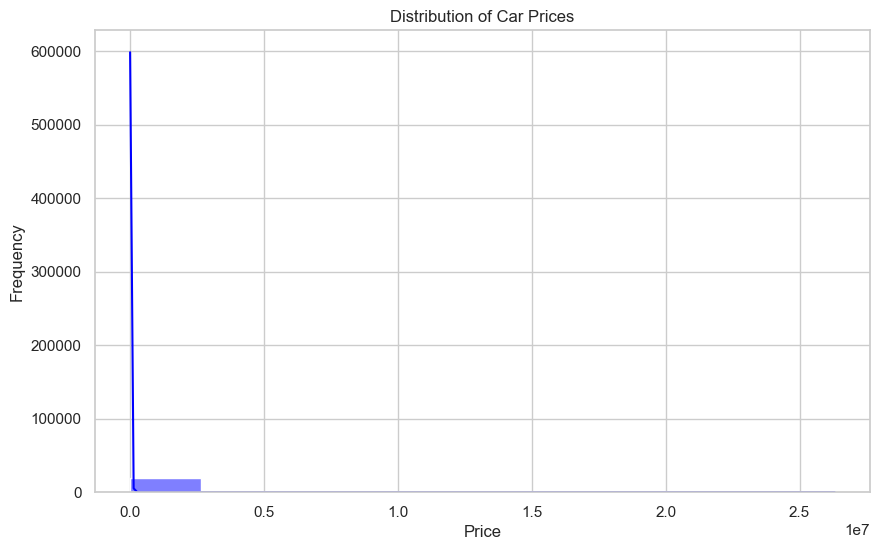

In [13]:
plt.figure(figsize=(10, 6))

# Plot the distribution of the target variable
sns.histplot(df['Price'], bins=10, kde=True, color='blue')

plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# 6. Categorical Features vs. Price
We investigate how categorical variables (e.g., fuel type, transmission) affect the car price. A boxplot is excellent for visualizing the median, quartiles, and potential outliers across different categories.

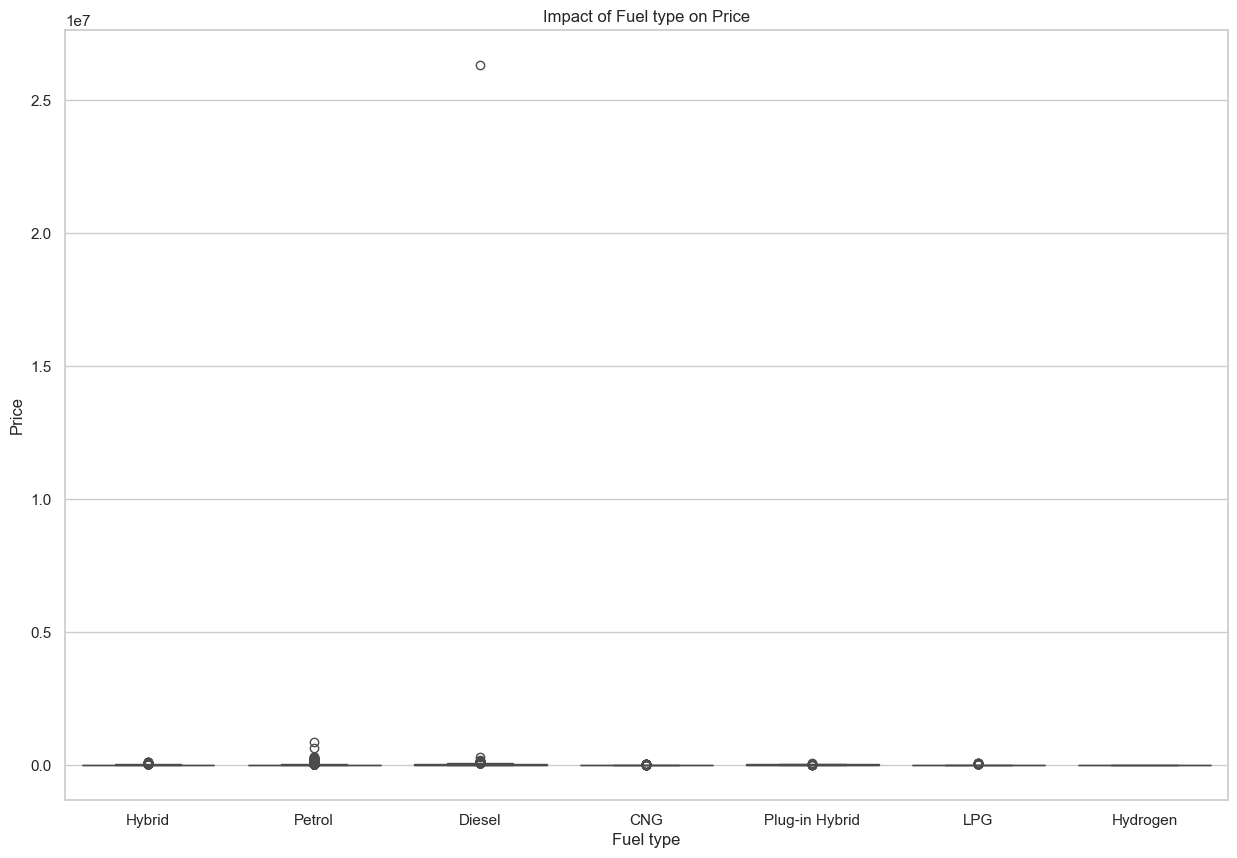

In [20]:
plt.figure(figsize=(15, 10))

# Boxplot for a categorical feature vs price (change 'fuel_type' if needed)
sns.boxplot(x='Fuel type', y='Price', data=df)

plt.title('Impact of Fuel type on Price')
plt.xlabel('Fuel type')
plt.ylabel('Price')
plt.show()

# 7. Correlation Heatmap
The correlation heatmap displays the linear relationship between numerical features. Features with a high positive or negative correlation with the 'price' column are strong predictors for our machine learning model.

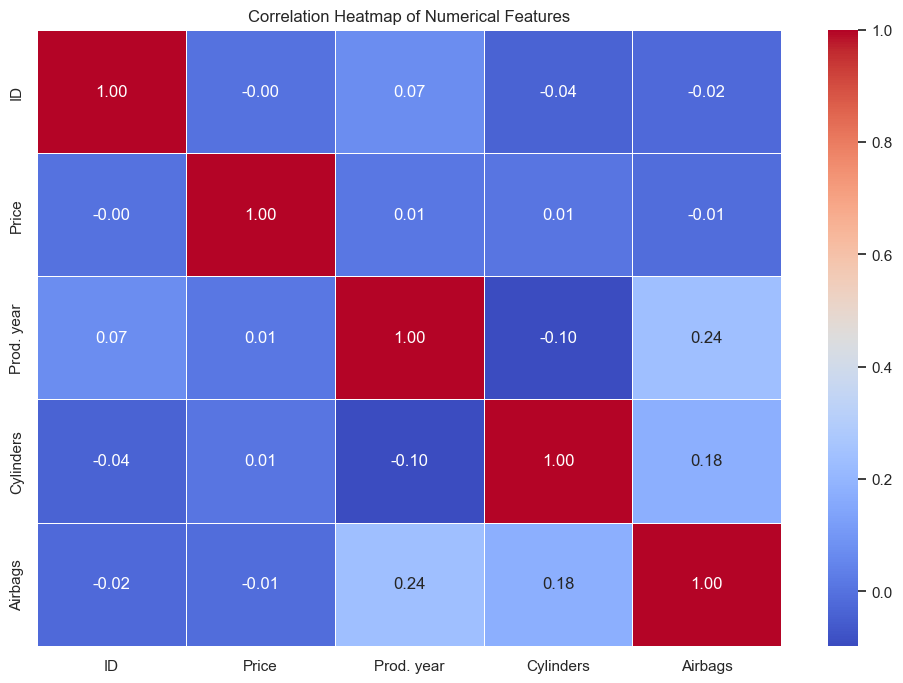

In [8]:
plt.figure(figsize=(12, 8))

# Select only numerical columns for correlation calculation
numeric_cols = df.select_dtypes(include=['int64', 'float64'])

# Plot the correlation heatmap
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### 8. Price Trends over Time
This scatter plot represents the relationship between a car's age and its market value.
* **Insight:** We can observe a clear **upward trend**; as the production year increases, the price distribution shifts higher.
* **Density:** The highest density of listings is found in cars manufactured between **2010 and 2018**.


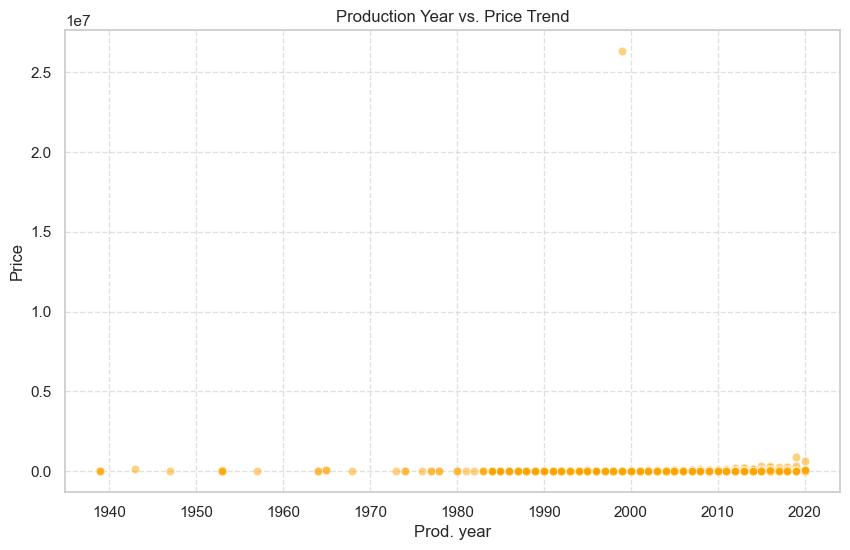

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Prod. year', y='Price', alpha=0.5, color='orange')
plt.title('Production Year vs. Price Trend')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 9. Model Insights: What Drives the Price?
After training the **Random Forest Regressor**, we extracted the feature importance scores to see which factors the model relied on most.
* **Top Predictors:** `Production Year` was the #1 factor, followed closely by `Manufacturer` and `Engine Volume`.
* **Conclusion:** This confirms that the model is making "logical" decisions similar to a human car expert.


Loading data for visualization...
Training model for feature insights...


C:\Users\lap shop\AppData\Local\Temp\ipykernel_9660\2163415514.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')


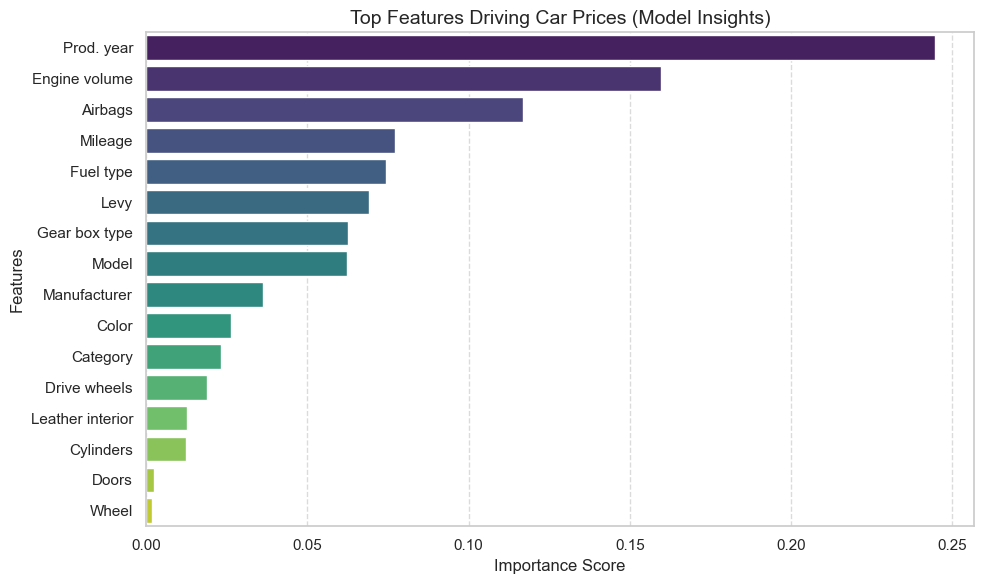

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from preprocessing import clean_data

# 1. Load and Preprocess Data (to define X and model)
print("Loading data for visualization...")
raw_data = pd.read_csv('data/train.csv')
df = clean_data(raw_data)

# Define Features (X) and Target (y)
X = df.drop(['Price', 'ID'], axis=1)
y = df['Price']

# 2. Train the Model in memory
print("Training model for feature insights...")
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

# 3. Extract and Plot Feature Importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

# Set plot style
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')

# Adding Titles and Labels
plt.title('Top Features Driving Car Prices (Model Insights)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

---

## 🏁 Final Conclusion & Summary

After a deep dive into the **Car Price Prediction** dataset through Exploratory Data Analysis (EDA), here are the key takeaways:

### 1. 📈 Key Price Drivers
* **Production Year:** There is a strong positive correlation between the car's age and its price. Newer models consistently command higher market values.
* **Engine Volume:** Larger engines generally lead to higher prices, though this varies significantly between fuel types.
* **Fuel & Gearbox:** Automatic transmissions and Diesel/Electric fuel types show a higher price baseline compared to Manual and Petrol variants.

### 2. ⚠️ Data Quality Challenges (The "Noisy" Data)
* **Outliers:** We identified significant price outliers (e.g., cars priced at **$1** or over **$1,000,000**). These anomalies are unrealistic and would mislead the machine learning model if not handled.
* **Missing Values:** Some features contain null values that require strategic imputation (Median/Mode) before training.

### 3. 🛠️ Next Steps: Transition to Modeling
The data is rich with information but requires a robust **Preprocessing Pipeline**:
1. **Filtering:** Removing extreme price outliers to stabilize the model.
2. **Encoding:** Transforming categorical features (Manufacturer, Category, Fuel Type) into numerical values using **Label Encoding**.
3. **Training:** Moving forward with the **Random Forest Regressor** to build the final prediction engine.

---

**Prepared by:** 👤 **Youssef Mohamed Elbaz** *Graphic Designer & Data Science Enthusiast* [🔗 View Project on GitHub](https://github.com/youssefelbaz99/car_price_prediction)

---